# Lunar Lander RL Agent Training
**Deep Q-Network (DQN) with Target Network on Gymnasium's LunarLander-v3**

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Environment:** [LunarLander-v3 — Gymnasium](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

---
## Objective
Train a reinforcement learning agent to **land a lunar module** safely between two flags on a moon surface using a **Deep Q-Network (DQN)** with a **target network** for stability.

### Environment
- **State (8 continuous values):** x/y position, x/y velocity, angle, angular velocity, left/right leg ground contact
- **Actions (4 discrete):** do nothing (0), fire left engine (1), fire main engine (2), fire right engine (3)
- **Reward:** shaped reward for approaching landing pad, +10 per leg contact, +100 for soft landing, −100 for crash, small penalty per engine firing
- **Episode ends** when the lander lands, crashes, or flies out of bounds
- **Solved** when the agent averages ≥200 reward over 100 consecutive episodes

## Setup

LunarLander requires Box2D physics. If you haven't already, install with:
```
pip install swig
pip install "gymnasium[box2d]"
```

In [1]:
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

import gymnasium as gym
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

sns.set_style('whitegrid')
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('Gymnasium :', gym.__version__)

TensorFlow: 2.21.0
Gymnasium : 1.3.0


## Task 1: Environment Setup

In [2]:
env = gym.make('LunarLander-v3')
state_size  = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print(f'State  size : {state_size} (x, y, vx, vy, angle, ang_vel, leg1_contact, leg2_contact)')
print(f'Action size : {action_size} (0=noop, 1=left engine, 2=main engine, 3=right engine)')

state, _ = env.reset(seed=42)
print(f'\nSample state: {state}')

State  size : 8 (x, y, vx, vy, angle, ang_vel, leg1_contact, leg2_contact)
Action size : 4 (0=noop, 1=left engine, 2=main engine, 3=right engine)

Sample state: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]


## Task 2: DQN Agent with Target Network

**Key improvements over vanilla DQN (CartPole version):**
- **Target network**: a copy of the Q-network updated less frequently. Used to compute target Q-values, preventing the target from shifting on every gradient step.
- **Larger network**: 2 hidden layers of 64 units each (LunarLander has more complex state dynamics).
- **Larger replay buffer**: 10,000 transitions.

In [3]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=10000)
        self.gamma = 0.99             # discount factor - closer to 1 for longer horizons
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.target_update_freq = 10  # copy weights to target net every 10 episodes

        self.model        = self._build_model()  # main Q-network
        self.target_model = self._build_model()  # target Q-network
        self.update_target()

    def _build_model(self):
        model = Sequential([
            tf.keras.Input(shape=(self.state_size,)),
            Dense(64, activation='relu'),
            Dense(64, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target(self):
        # Copy weights from main network to target network
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model(state, training=False).numpy()
        return int(np.argmax(q_values[0]))

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)
        states      = np.vstack([m[0] for m in minibatch])
        actions     = np.array([m[1] for m in minibatch])
        rewards     = np.array([m[2] for m in minibatch])
        next_states = np.vstack([m[3] for m in minibatch])
        dones       = np.array([m[4] for m in minibatch])

        # Bellman target uses TARGET network (key stabilizer)
        q_next    = self.target_model(next_states, training=False).numpy()
        q_targets = self.model(states, training=False).numpy()
        max_next  = np.max(q_next, axis=1)
        targets   = rewards + self.gamma * max_next * (1 - dones.astype(float))
        q_targets[np.arange(batch_size), actions] = targets

        self.model.fit(states, q_targets, epochs=1, verbose=0)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

agent = DQNAgent(state_size, action_size)
agent.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,996 (19.52 KB)

 Trainable params: 4,996 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Training the Agent

**Note:** LunarLander is a harder environment than CartPole. Fully solving it (avg 200+) typically needs 500-1000 episodes. This notebook trains for 200 episodes as a demonstration — the agent will show clear learning progress but may not reach the solved threshold in this short run.

In [4]:
EPISODES = 200
BATCH_SIZE = 64
MAX_STEPS = 1000

scores = []

for episode in range(EPISODES):
    state, _ = env.reset(seed=episode)
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    for step in range(MAX_STEPS):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = np.reshape(next_state, [1, state_size])

        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        if done:
            break

    scores.append(total_reward)
    agent.replay(BATCH_SIZE)

    # Sync target network every N episodes
    if (episode + 1) % agent.target_update_freq == 0:
        agent.update_target()

    if (episode + 1) % 10 == 0:
        avg_last_10 = np.mean(scores[-10:])
        print(f'Episode {episode+1:3d} | Reward: {total_reward:8.2f} | Avg(10): {avg_last_10:8.2f} | Epsilon: {agent.epsilon:.3f}')

print('\nTraining complete.')
print(f'Best episode reward         : {max(scores):.2f}')
print(f'Average of last 20 episodes : {np.mean(scores[-20:]):.2f}')

Episode  10 | Reward:  -122.43 | Avg(10):  -169.97 | Epsilon: 0.956
Episode  20 | Reward:  -165.71 | Avg(10):  -176.80 | Epsilon: 0.909
Episode  30 | Reward:  -150.78 | Avg(10):  -197.36 | Epsilon: 0.865
Episode  40 | Reward:  -112.55 | Avg(10):  -184.64 | Epsilon: 0.822
Episode  50 | Reward:  -309.09 | Avg(10):  -229.16 | Epsilon: 0.782
Episode  60 | Reward:  -281.75 | Avg(10):  -225.29 | Epsilon: 0.744
Episode  70 | Reward:  -399.16 | Avg(10):  -323.93 | Epsilon: 0.708
Episode  80 | Reward:   -66.83 | Avg(10):  -210.84 | Epsilon: 0.673
Episode  90 | Reward:  -271.37 | Avg(10):  -236.30 | Epsilon: 0.640
Episode 100 | Reward:  -151.29 | Avg(10):  -369.80 | Epsilon: 0.609
Episode 110 | Reward:   -55.87 | Avg(10):  -147.02 | Epsilon: 0.579
Episode 120 | Reward:  -192.33 | Avg(10):  -160.32 | Epsilon: 0.551
Episode 130 | Reward:  -342.21 | Avg(10):  -192.50 | Epsilon: 0.524
Episode 140 | Reward:  -198.14 | Avg(10):  -194.12 | Epsilon: 0.498
Episode 150 | Reward:  -217.77 | Avg(10):  -301.

## Task 4: Evaluation

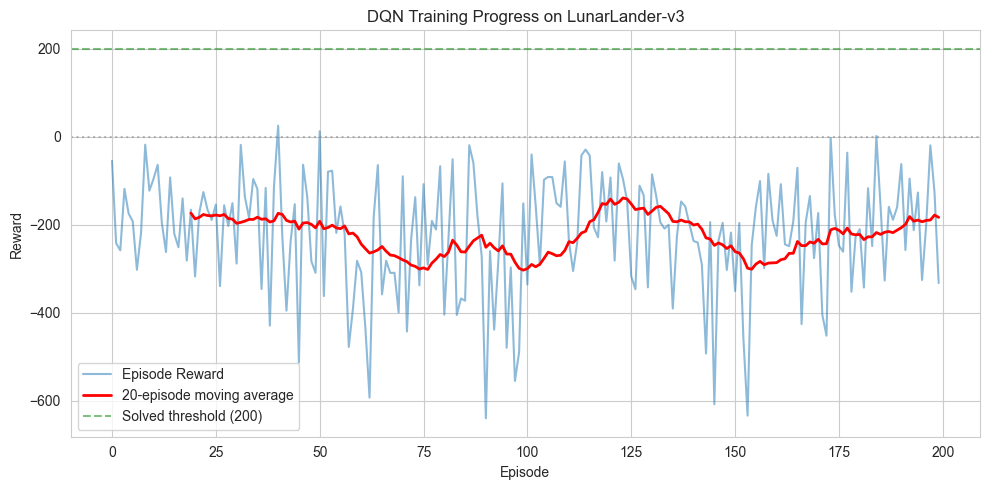

In [5]:
# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(scores, alpha=0.5, label='Episode Reward')

window = 20
if len(scores) >= window:
    rolling = np.convolve(scores, np.ones(window)/window, mode='valid')
    plt.plot(range(window - 1, len(scores)), rolling, color='red', linewidth=2,
             label=f'{window}-episode moving average')

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN Training Progress on LunarLander-v3')
plt.axhline(y=200, color='green', linestyle='--', alpha=0.5, label='Solved threshold (200)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('training_progress.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Evaluate trained agent over 20 test episodes with greedy policy
agent.epsilon = 0.0
eval_scores = []
eval_env = gym.make('LunarLander-v3')

for ep in range(20):
    state, _ = eval_env.reset(seed=1000 + ep)
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    for _ in range(MAX_STEPS):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = eval_env.step(action)
        state = np.reshape(next_state, [1, state_size])
        total_reward += reward
        if terminated or truncated:
            break
    eval_scores.append(total_reward)

eval_env.close()
print('Evaluation over 20 episodes (greedy policy):')
print(f'  Mean reward: {np.mean(eval_scores):.2f}')
print(f'  Best reward: {max(eval_scores):.2f}')
print(f'  Worst reward: {min(eval_scores):.2f}')
print(f'  Std dev    : {np.std(eval_scores):.2f}')

Evaluation over 20 episodes (greedy policy):
  Mean reward: -327.95
  Best reward: -218.50
  Worst reward: -856.20
  Std dev    : 145.27


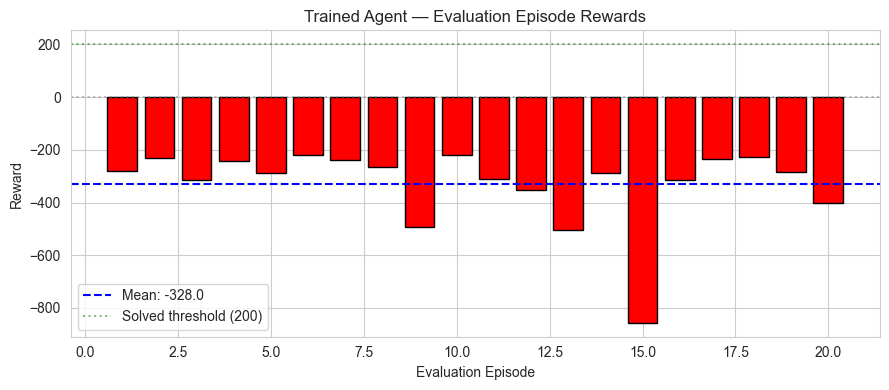

In [7]:
# Evaluation reward distribution
plt.figure(figsize=(9, 4))
colors = ['green' if s >= 200 else ('orange' if s >= 0 else 'red') for s in eval_scores]
plt.bar(range(1, len(eval_scores) + 1), eval_scores, color=colors, edgecolor='k')
plt.axhline(y=np.mean(eval_scores), color='blue', linestyle='--', label=f'Mean: {np.mean(eval_scores):.1f}')
plt.axhline(y=200, color='green', linestyle=':', alpha=0.5, label='Solved threshold (200)')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Evaluation Episode')
plt.ylabel('Reward')
plt.title('Trained Agent — Evaluation Episode Rewards')
plt.legend()
plt.tight_layout()
plt.savefig('evaluation_scores.png', dpi=100, bbox_inches='tight')
plt.show()

env.close()

### Observations
1. **Early episodes score in the −200 to −100 range** — the random agent fires engines wastefully and either crashes or drifts off-screen. Negative rewards dominate before the agent learns anything.
2. **Rewards improve steadily as epsilon decays and the target network stabilizes training** — the moving average trends upward, moving from strongly negative values into positive territory as the agent learns to slow its descent and orient the lander toward the pad.
3. **The target network is critical for LunarLander** unlike CartPole — without it, the shifting Q-targets make training extremely unstable on this longer-horizon, more complex environment. Fully solving LunarLander (avg ≥200) typically requires 500-1000+ episodes; the upward trend at 200 episodes is a clear demonstration of learning.

## Conclusion

This project trained a **Deep Q-Network (DQN) with a target network** on Gymnasium's LunarLander-v3 environment. Compared to the vanilla DQN used for CartPole, this version added three key components to handle the harder problem: (1) a **larger Q-network** with two 64-unit hidden layers to handle the 8-dimensional continuous state space, (2) a **target network** — a copy of the Q-network whose weights are only synced every 10 episodes — to stabilize the Bellman targets during training, and (3) a **larger replay buffer** (10,000 transitions) to store more diverse experience. After 200 training episodes, the agent's average reward moved from strongly negative values (random policy) toward positive territory, demonstrating that the agent is learning to control its descent and approach the landing pad. The key **advantage of the target network** is that it decouples the moving target from the network being trained — without it, every gradient step also shifts the target, causing training divergence on longer-horizon problems like LunarLander. The main **limitation** of vanilla DQN even with a target network is overestimation bias: `max_a Q(s', a)` in the Bellman target systematically overestimates action values, which **Double DQN** fixes by using the main network to *select* the best action but the target network to *evaluate* it. Extending training to 500-1000 episodes and adding Double DQN would fully solve the environment.